In [1]:
%matplotlib inline

import datacube
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import sys
sys.path.insert(1, '../Tools/')

from dea_tools.datahandling import wofs_fuser
from dea_tools.plotting import plot_wo
from datacube.utils import masking

from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
dc = datacube.Datacube()

In [ ]:
# Set up query

# Lake Burley Griffin
latitude = (-35.31521270417865, -35.27891560240775)
longitude = (149.07109683414018, 149.15412159440436)

output_crs = "EPSG:3577"
output_res = 60 # metres
start_date = "2024-06-01"
end_date = "2024-12-31"

In [4]:
# Lazily load in S1NRB
s1 = dc.load(
    product='ga_s1_nrb_iw_vv_vh_0',
    measurements=["VV_gamma0", "VH_gamma0", "mask"],
    lat=latitude,
    lon=longitude,
    output_crs=output_crs,
    resolution=(output_res, -output_res),
    time=(start_date, end_date),
    group_by = 'solar_day',
    dask_chunks={}
)

In [5]:
# Lazily load in WoFs
wo = dc.load(
    product='ga_ls_wo_3',
    measurements = ['water'],
    lat=latitude,
    lon=longitude,
    output_crs=output_crs,
    resolution=(output_res, -output_res),
    time=(start_date, end_date),
    group_by = 'solar_day',
    fuse_func=wofs_fuser,
    dask_chunks={}
)

In [6]:
# Lazily load in Landsat
ls = dc.load(
    product=["ga_ls8c_ard_3","ga_ls9c_ard_3"],
    measurements=["nbart_red", "nbart_green", "nbart_blue"],
    lat=latitude,
    lon=longitude,
    output_crs=output_crs,
    resolution=(output_res, -output_res),
    time=(start_date, end_date),
    group_by = 'solar_day',
    dask_chunks={}
)

In [7]:
# Remove completely nan S1 timesteps
s1_null_mask = ~s1.VV_gamma0.isnull().all(dim=["x","y"])
s1_masked = s1.sel(time=s1_null_mask)

/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


In [8]:
# Keep only wet and dry pixels
wo_wet = masking.make_mask(wo, wet=True)
wo_dry = masking.make_mask(wo, dry=True)
wo_clear = wo_wet + wo_dry
wo_masked = wo_wet.where(wo_clear)

In [9]:
# Remove timesteps with less than 20 percent valid data
percent_nodata = wo_masked.water.isnull().mean(dim=['x', 'y'])
wo_masked = wo_masked.sel(time=(percent_nodata < 0.2))

In [10]:
len(s1_masked.time), len(wo_masked.time)

(33, 17)

In [11]:
# Ensure same number of timesteps for WO and S1
if len(wo_masked.time) <= len(s1_masked.time):
    s1_matched = s1_masked.sel(time=wo_masked.time, method='nearest')
    wo_matched = wo_masked
else:
    wo_matched = wo_masked.sel(time=s1_masked.time, method='nearest')
    s1_matched = s1_masked

In [12]:
len(s1_matched.time), len(wo_matched.time)

(17, 17)

In [13]:
# Mask out nan values prior to fitting
nan_mask = ~np.isnan(wo_matched.water.values)
water_mask = wo_matched.water.values[nan_mask].flatten()
band1 = s1_matched.VH_gamma0.values[nan_mask].flatten()
band2 = s1_matched.VV_gamma0.values[nan_mask].flatten()

# Convert to dB scale
band1_db = 10 * np.log10(band1 + 1e-10)
band2_db = 10 * np.log10(band2 + 1e-10)

# Stack bands
bands_db = np.stack((band1_db, band2_db), axis=1)

In [14]:
# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    bands_db, water_mask, test_size=0.1, random_state=42
)

# Train SVM 
clf = make_pipeline(StandardScaler(), LinearSVC(random_state=0, tol=1e-5, max_iter=10000))
clf.fit(X_train, y_train)

# Evaluate on validation set
y_pred = clf.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97     15194
         1.0       0.87      0.79      0.83      2602

    accuracy                           0.95     17796
   macro avg       0.92      0.89      0.90     17796
weighted avg       0.95      0.95      0.95     17796



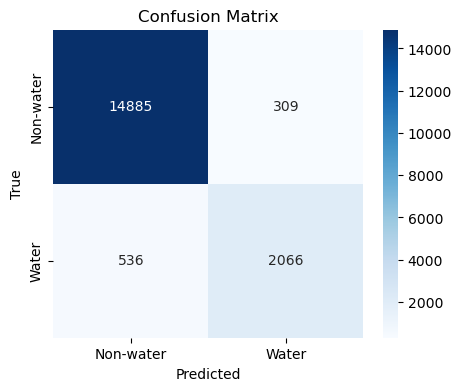

In [15]:
# Plot confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-water", "Water"], yticklabels=["Non-water", "Water"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

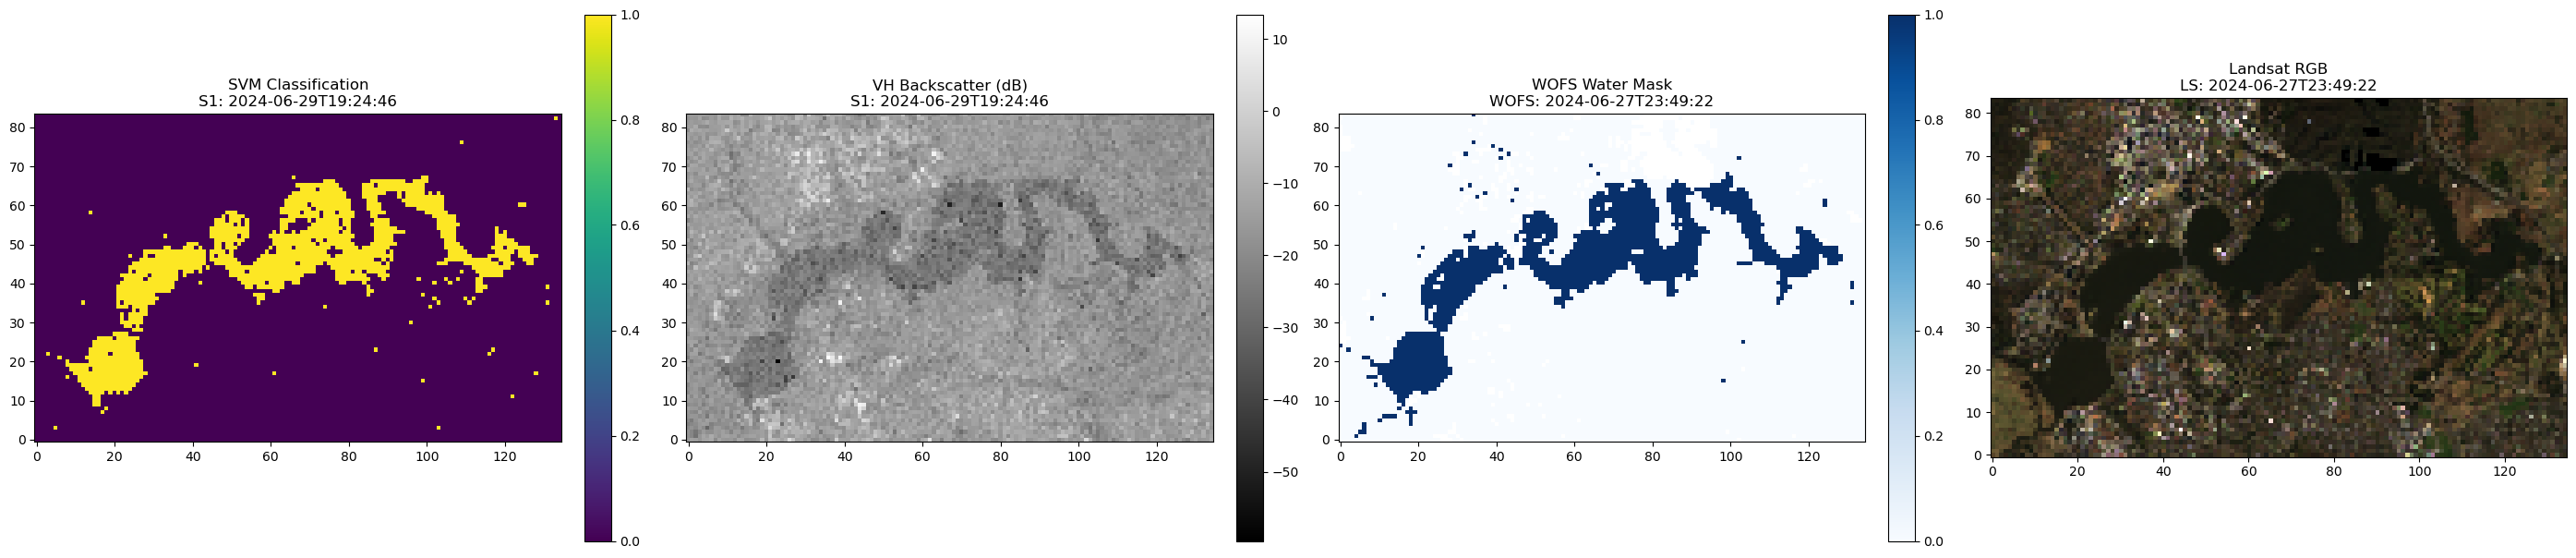

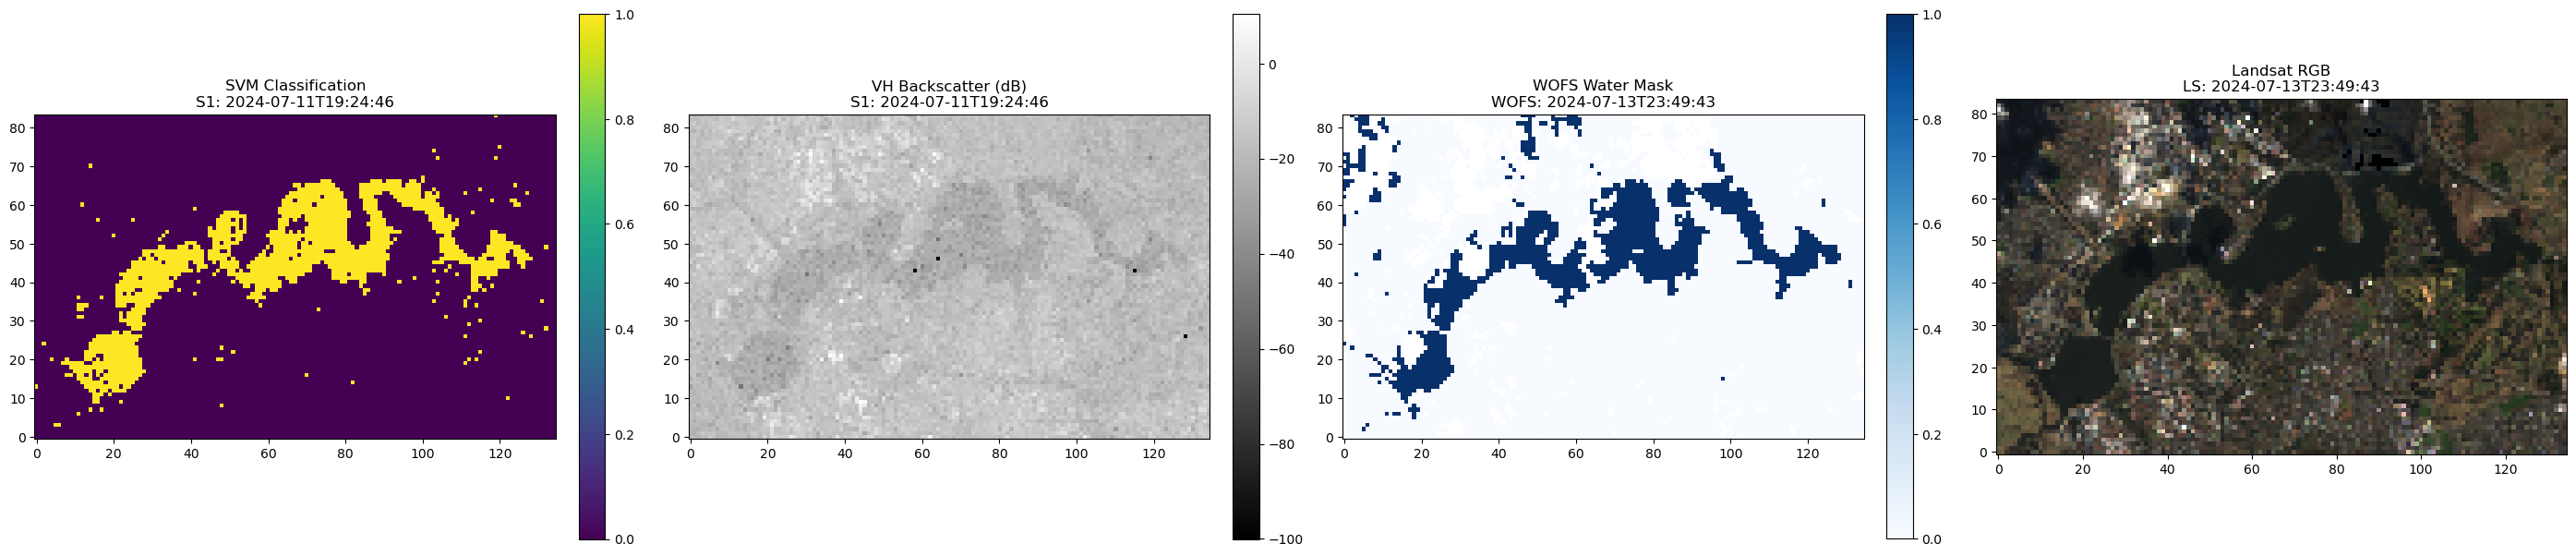

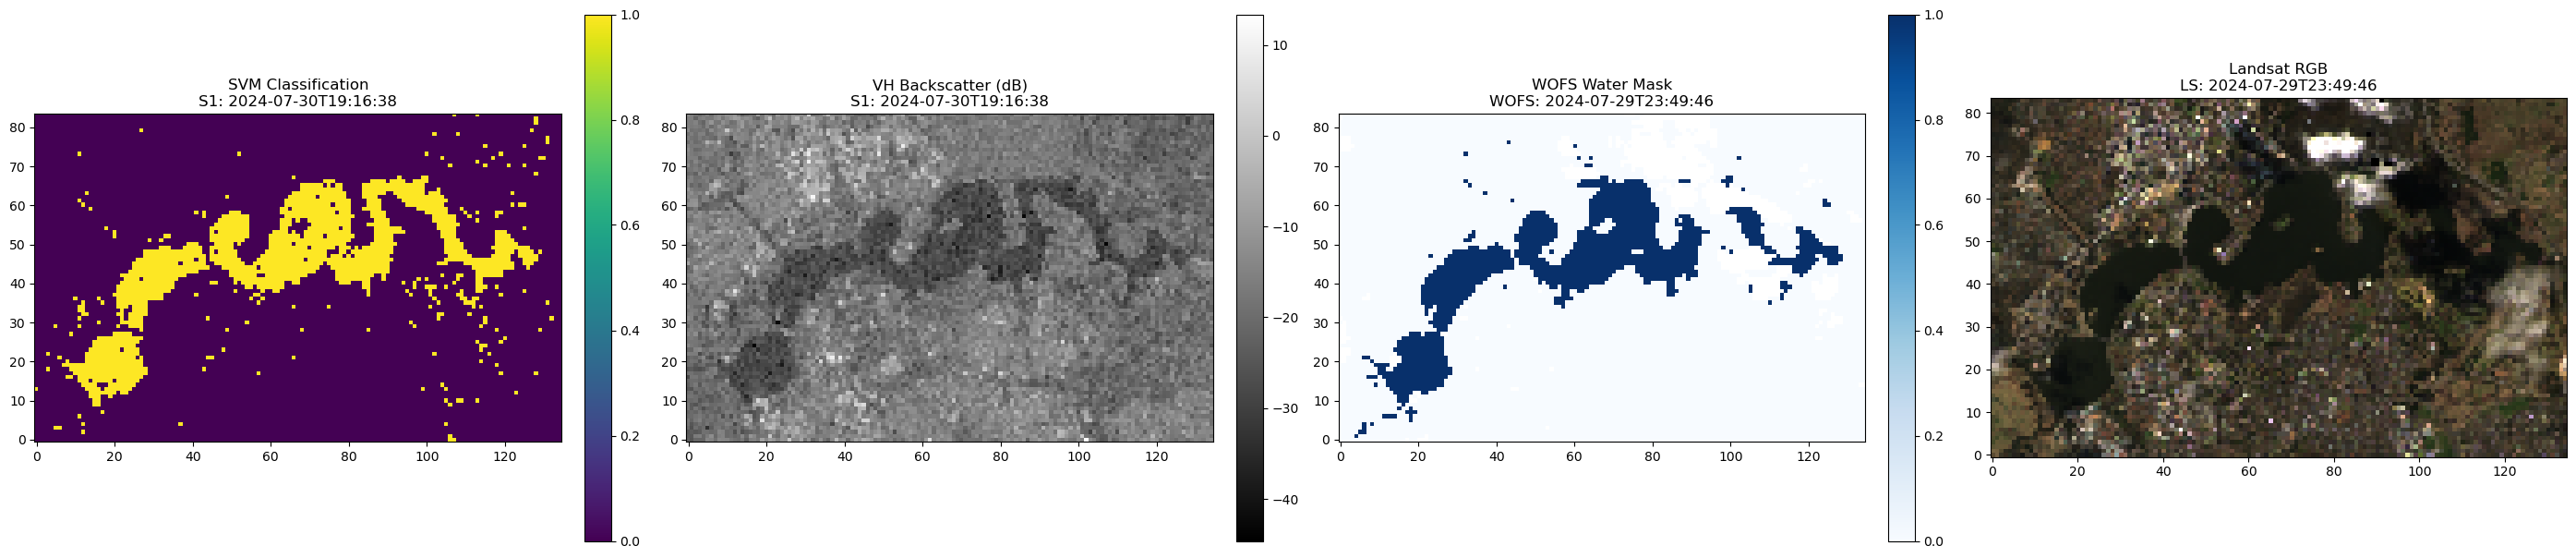

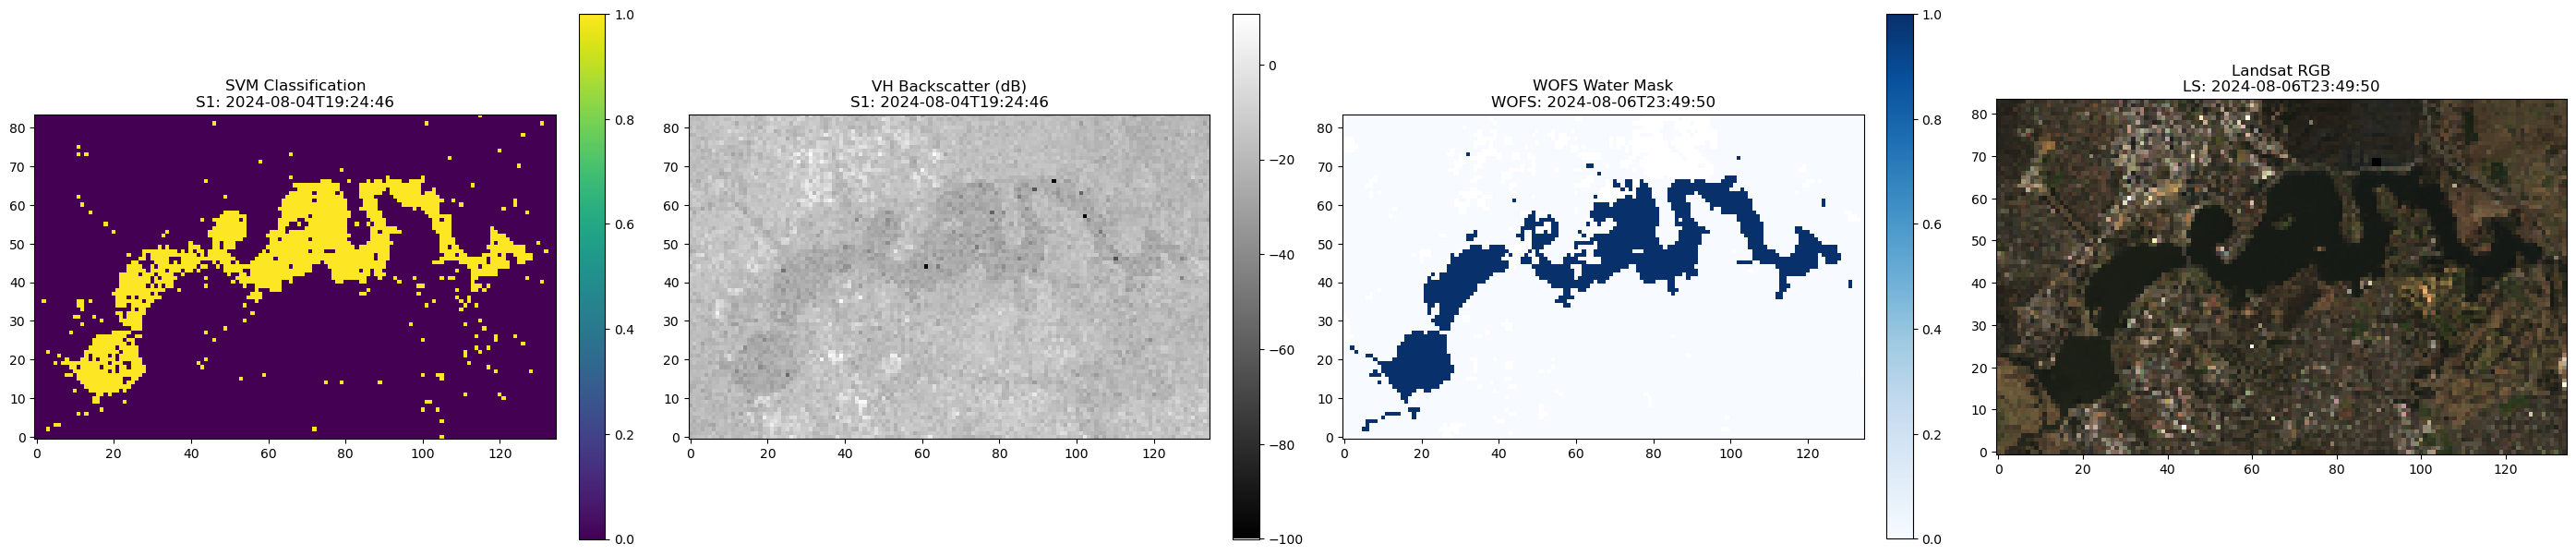

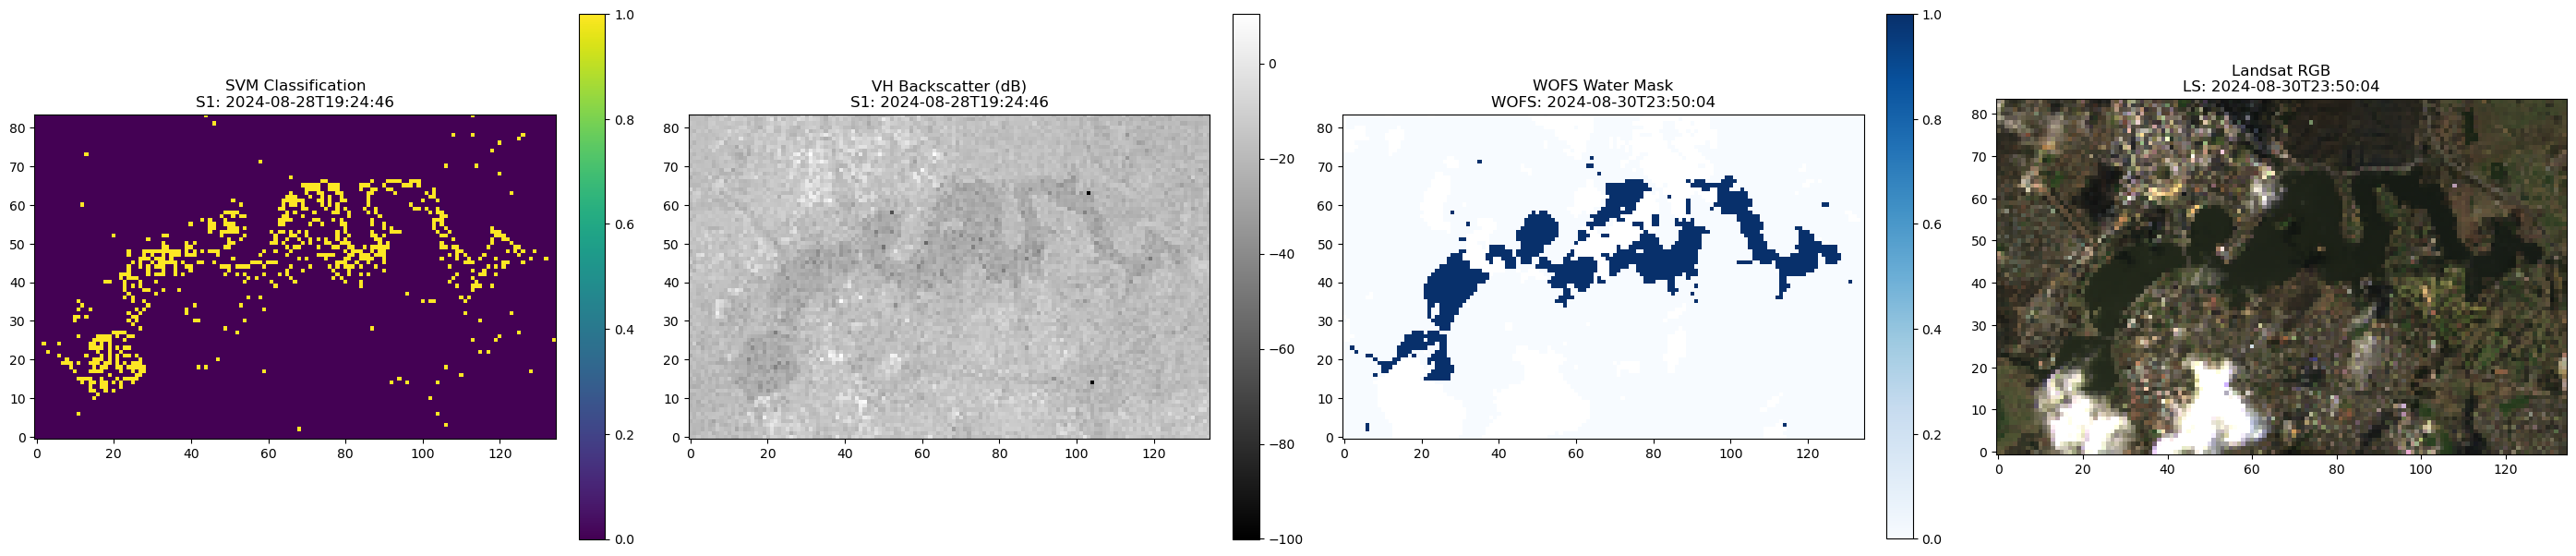

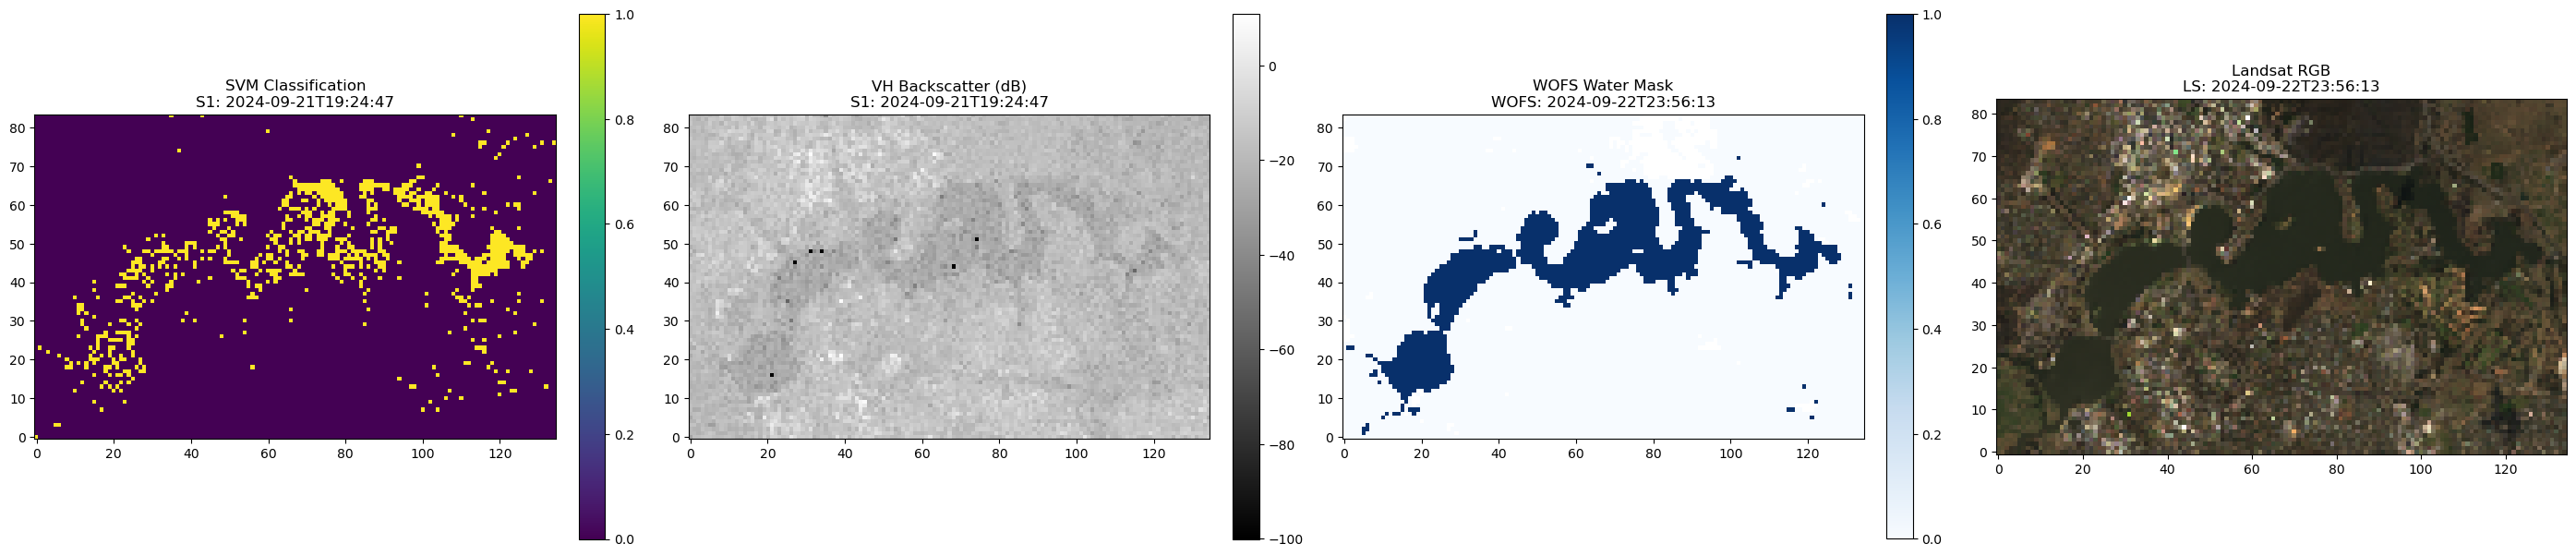

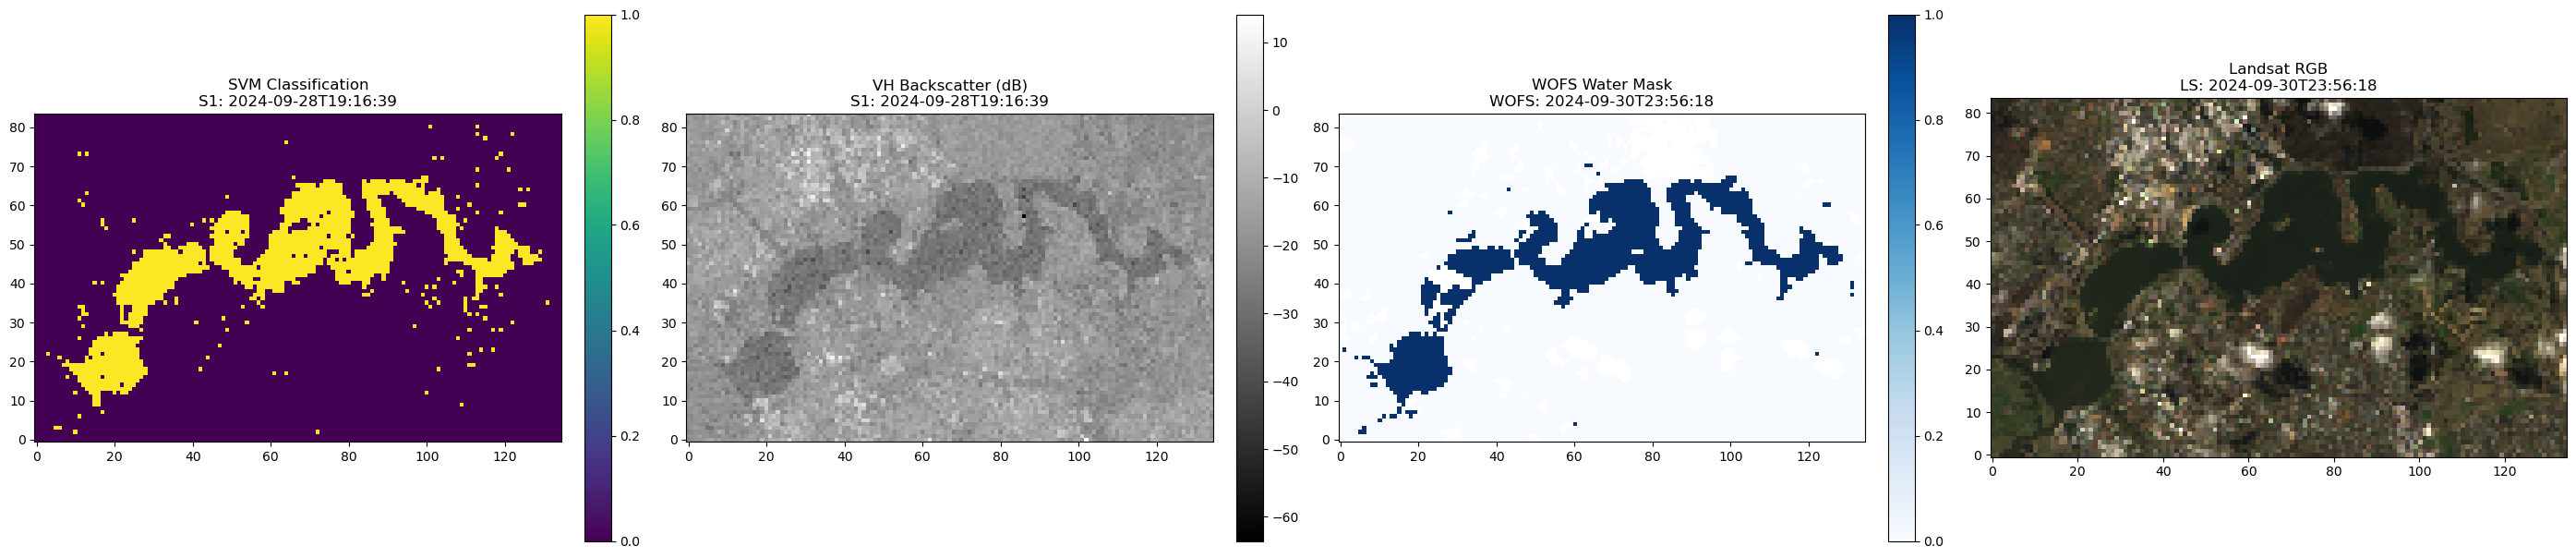

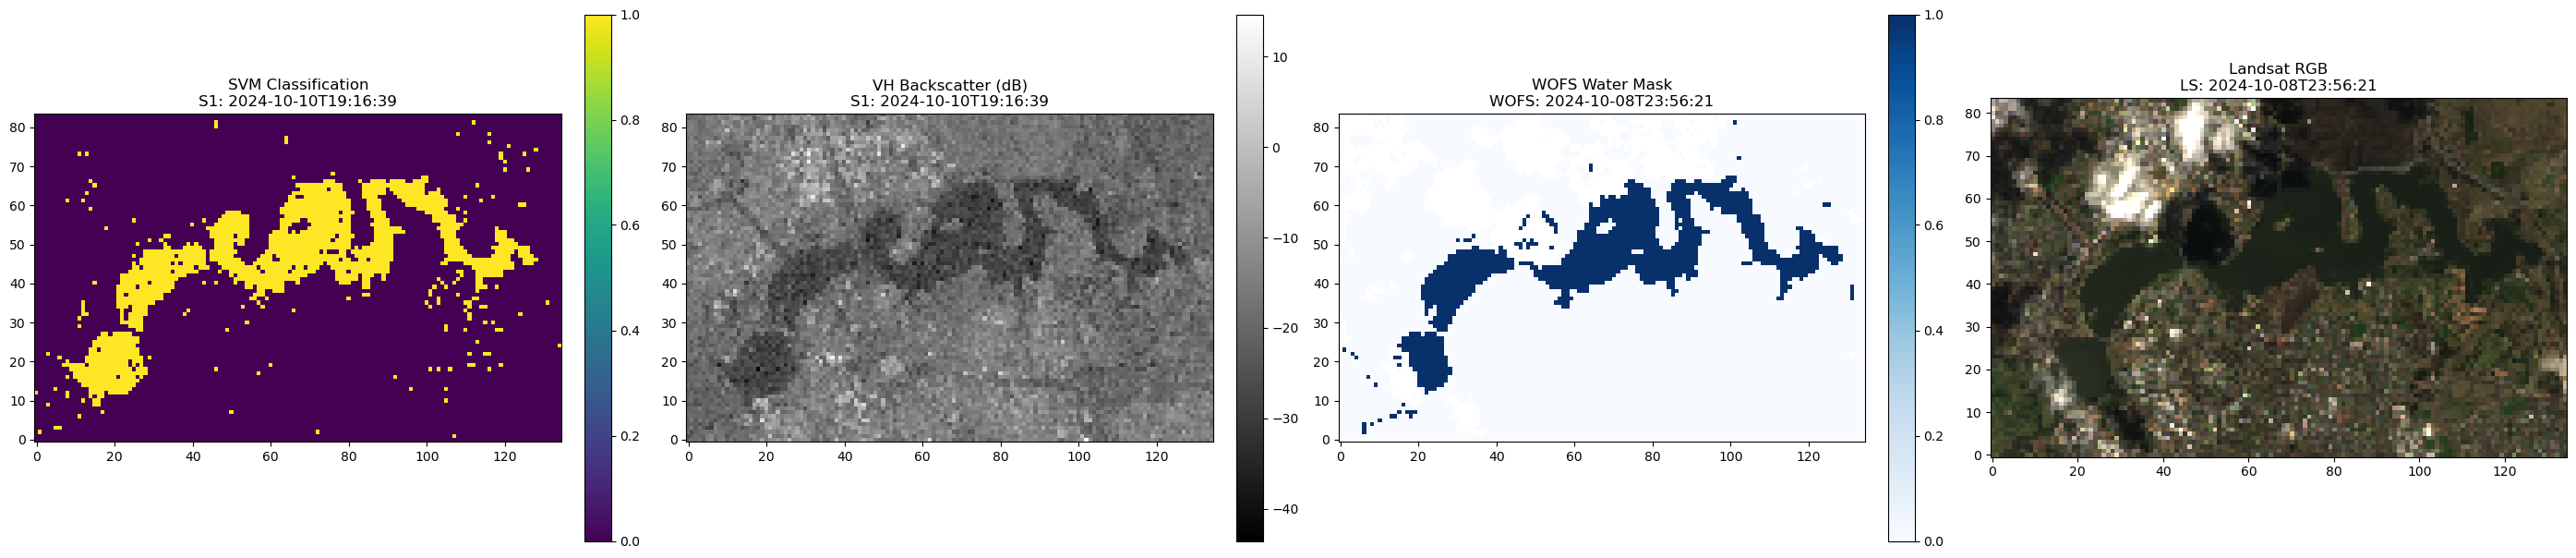

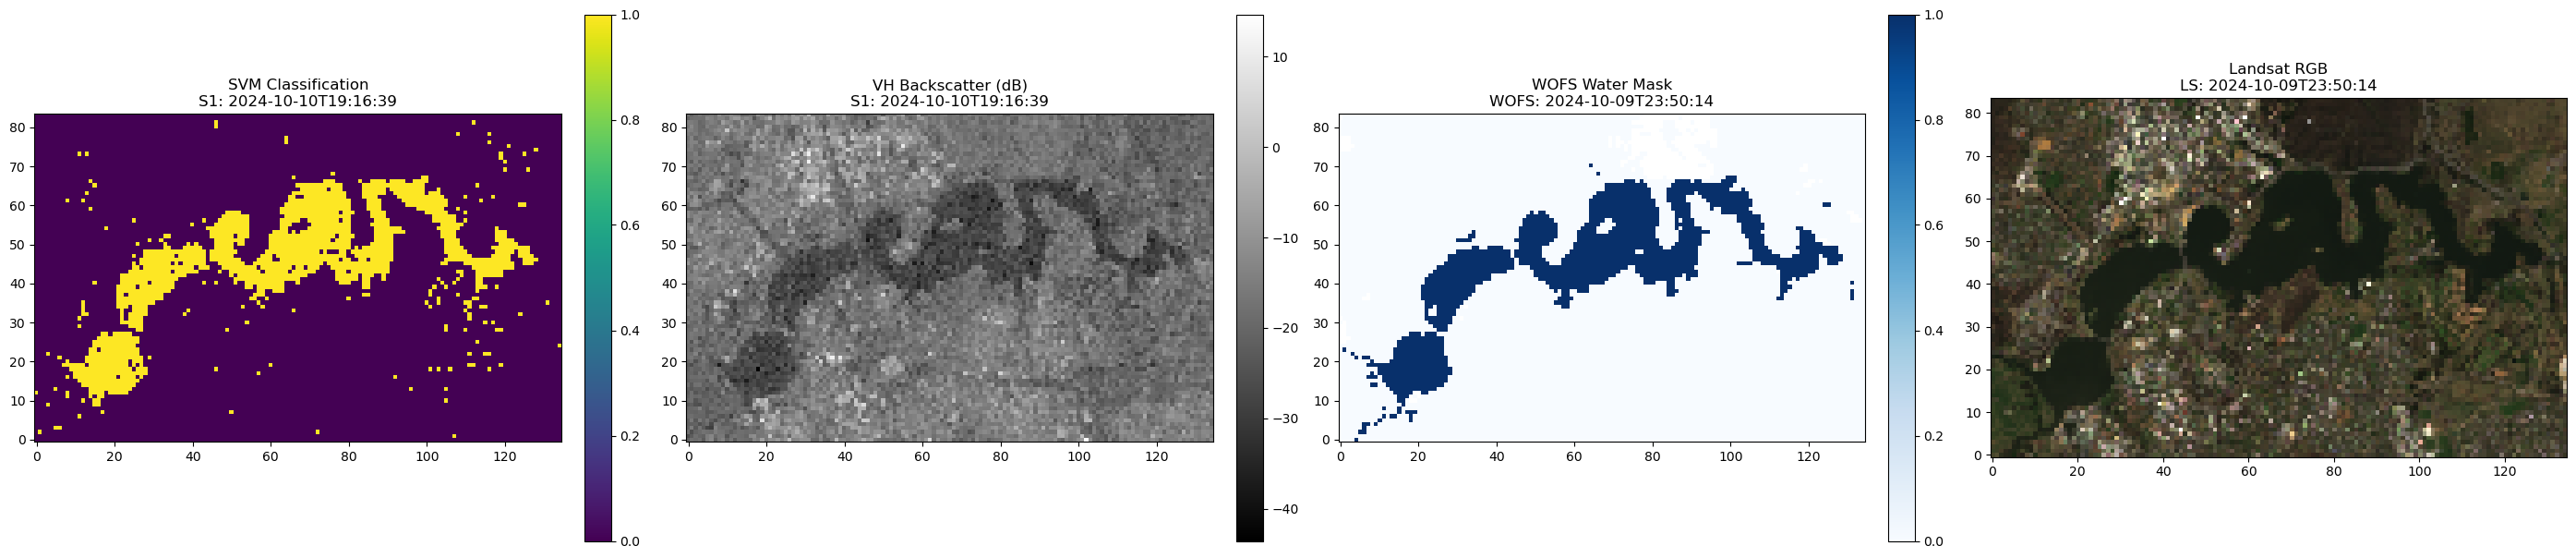

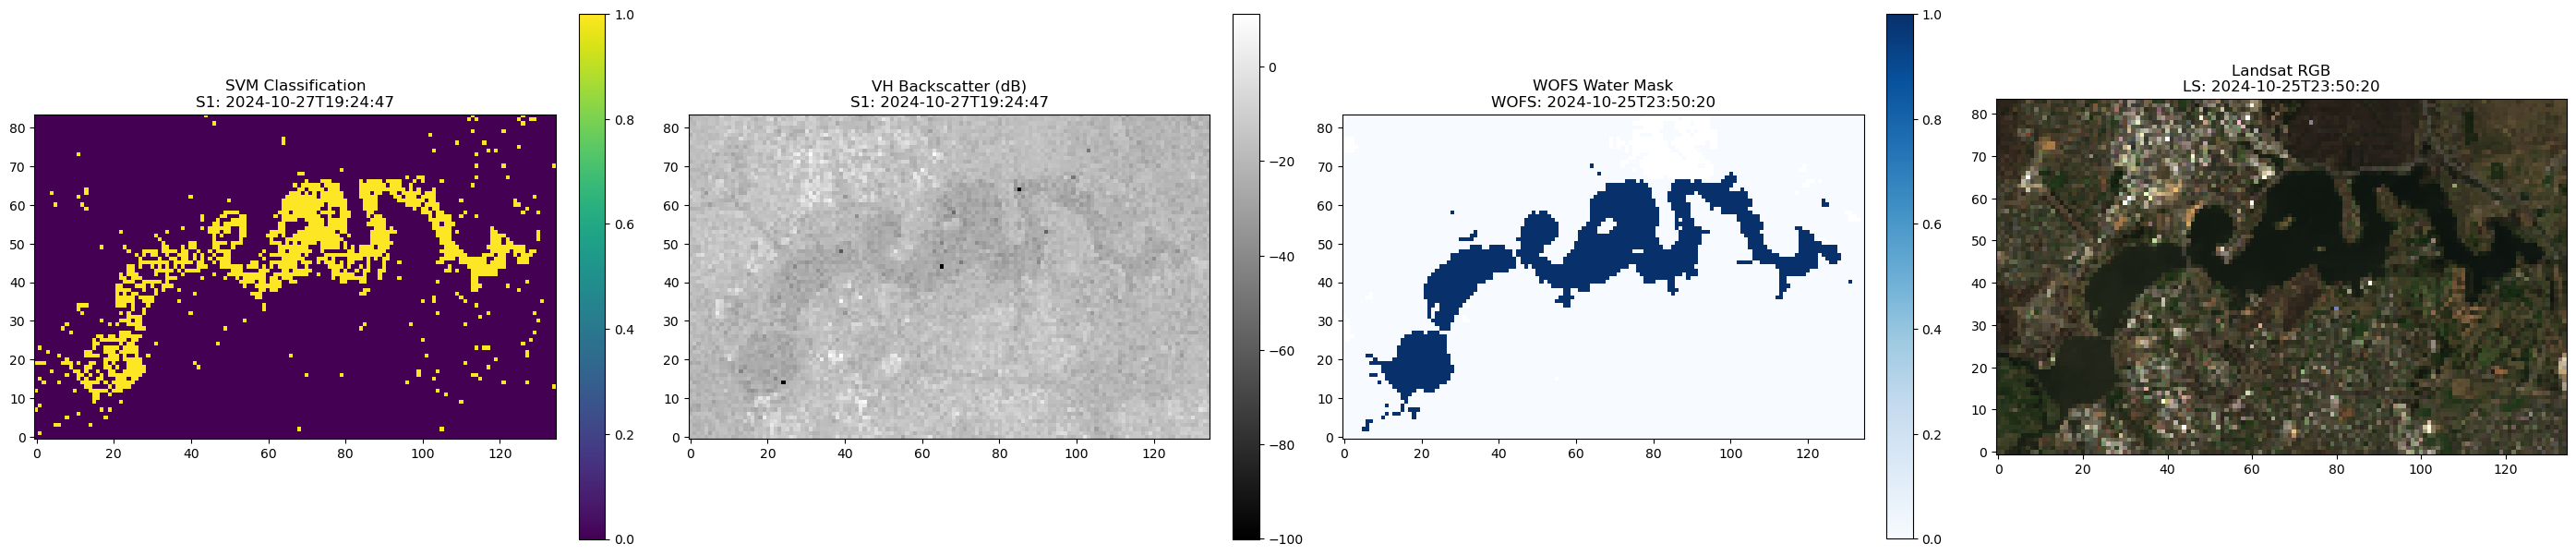

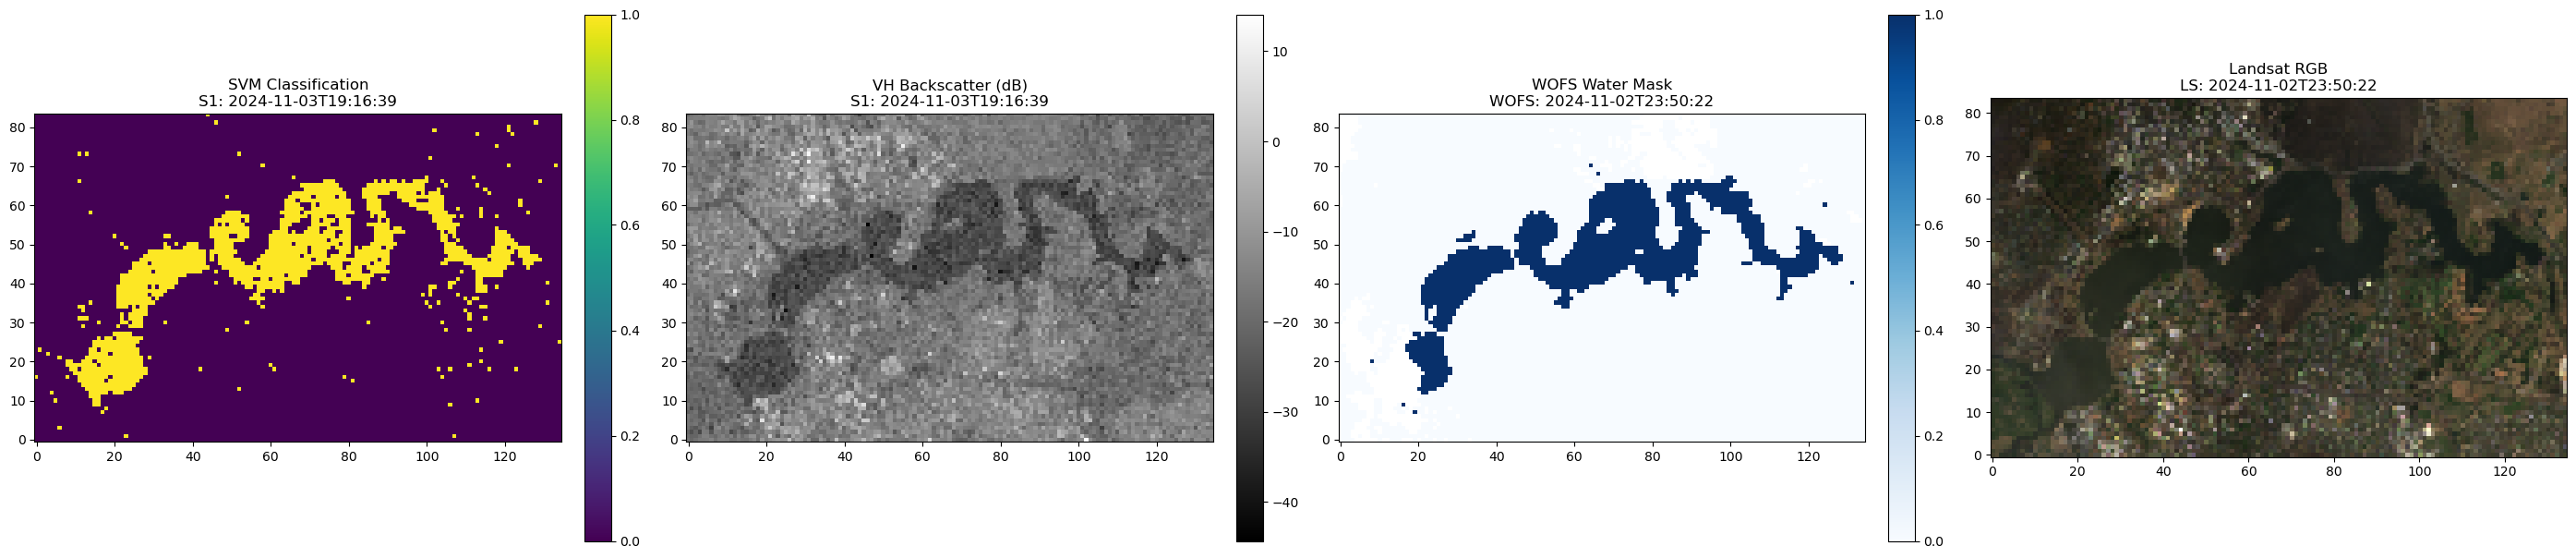

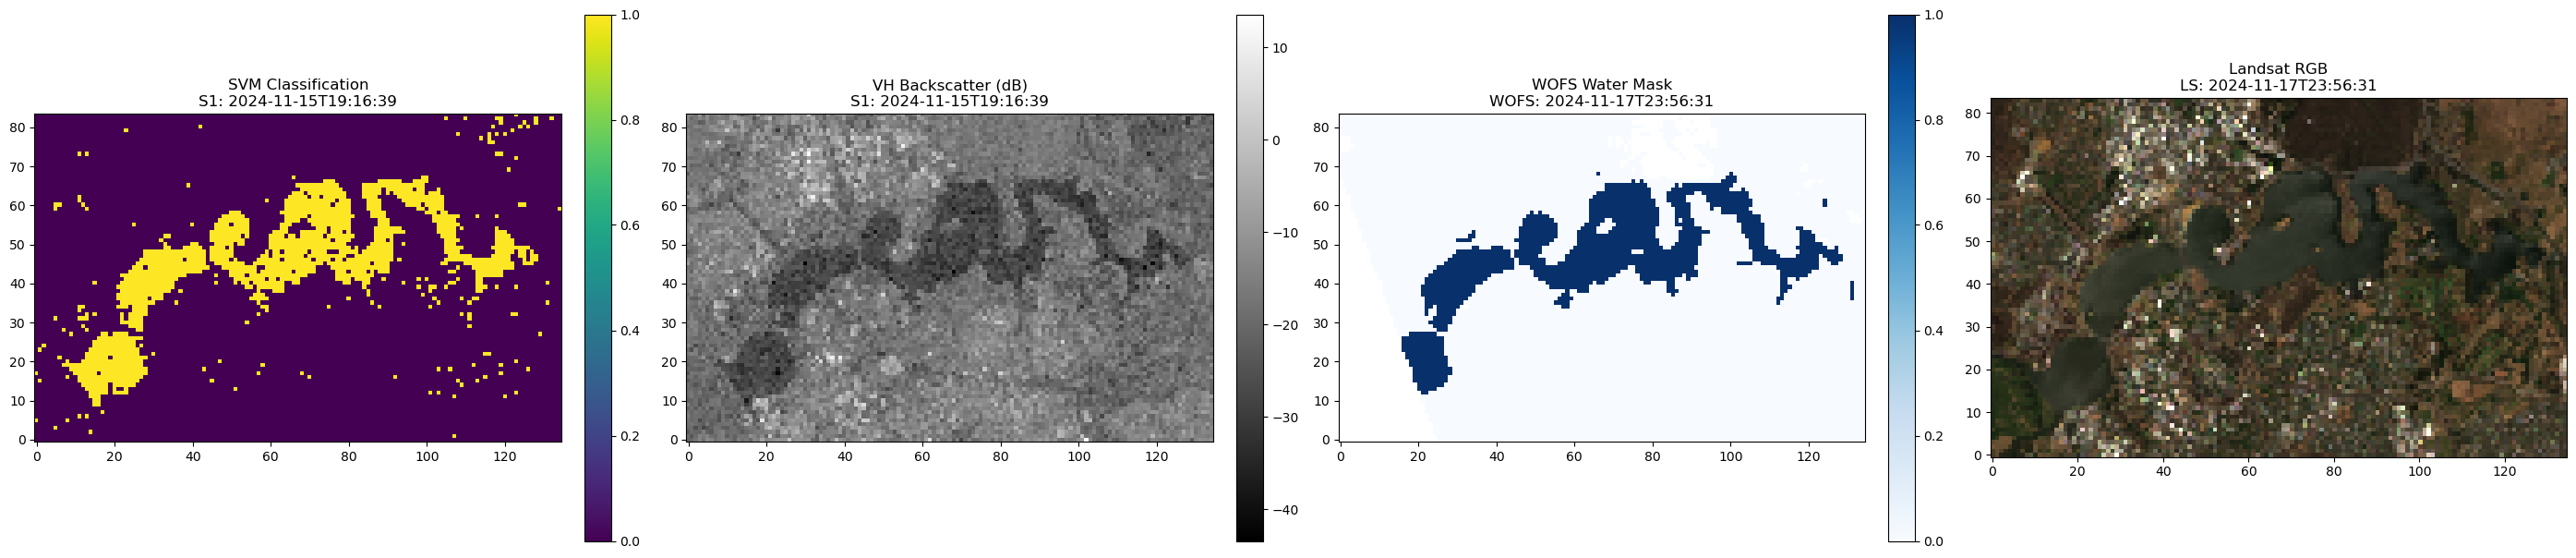

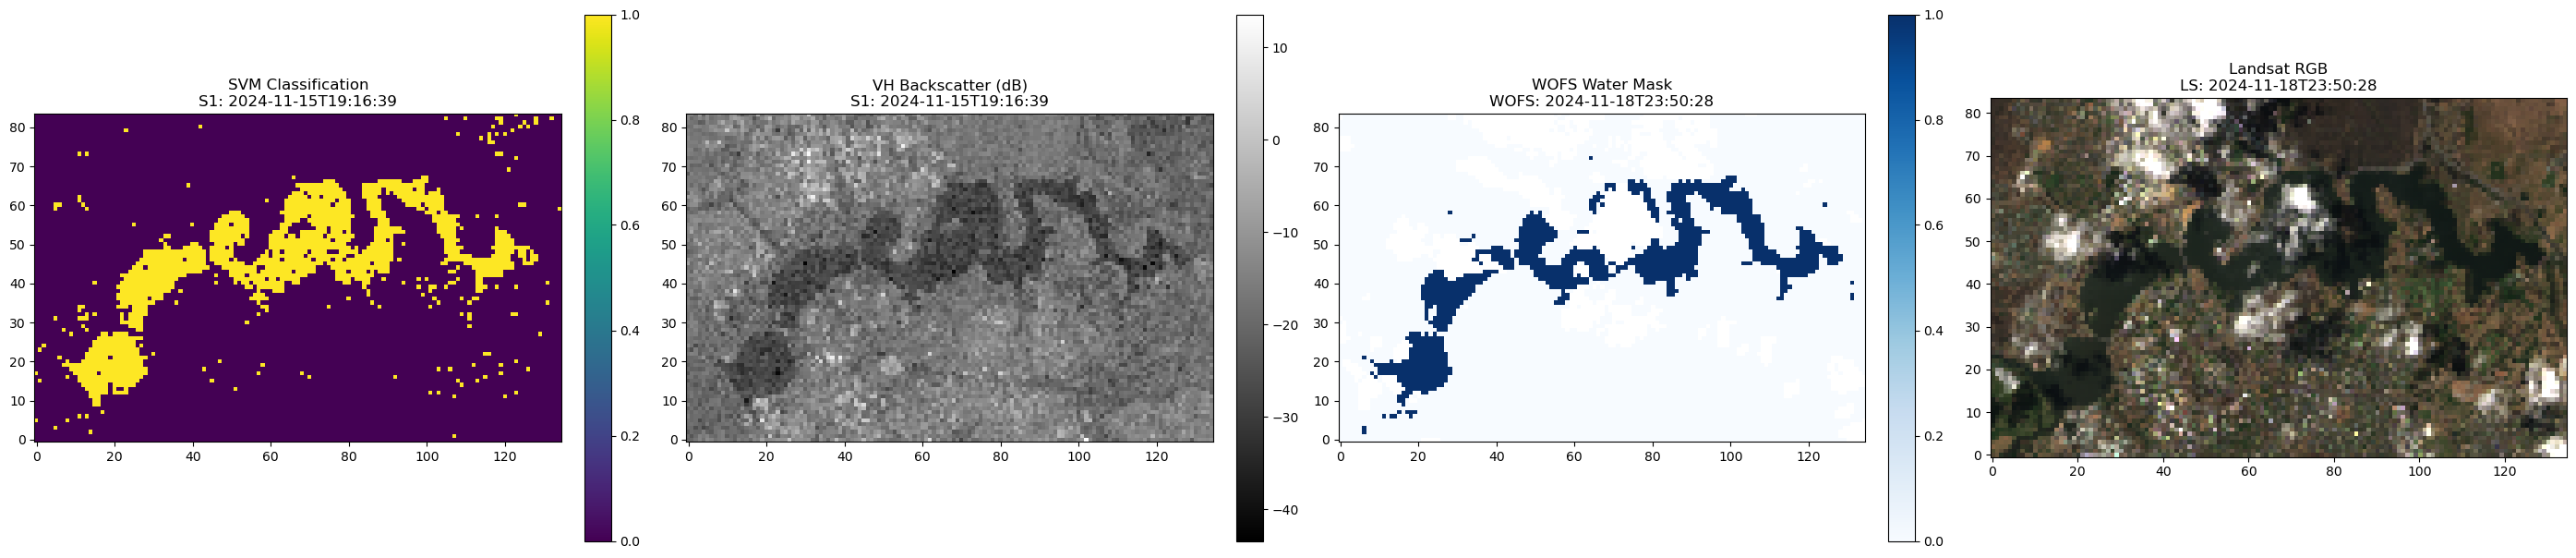

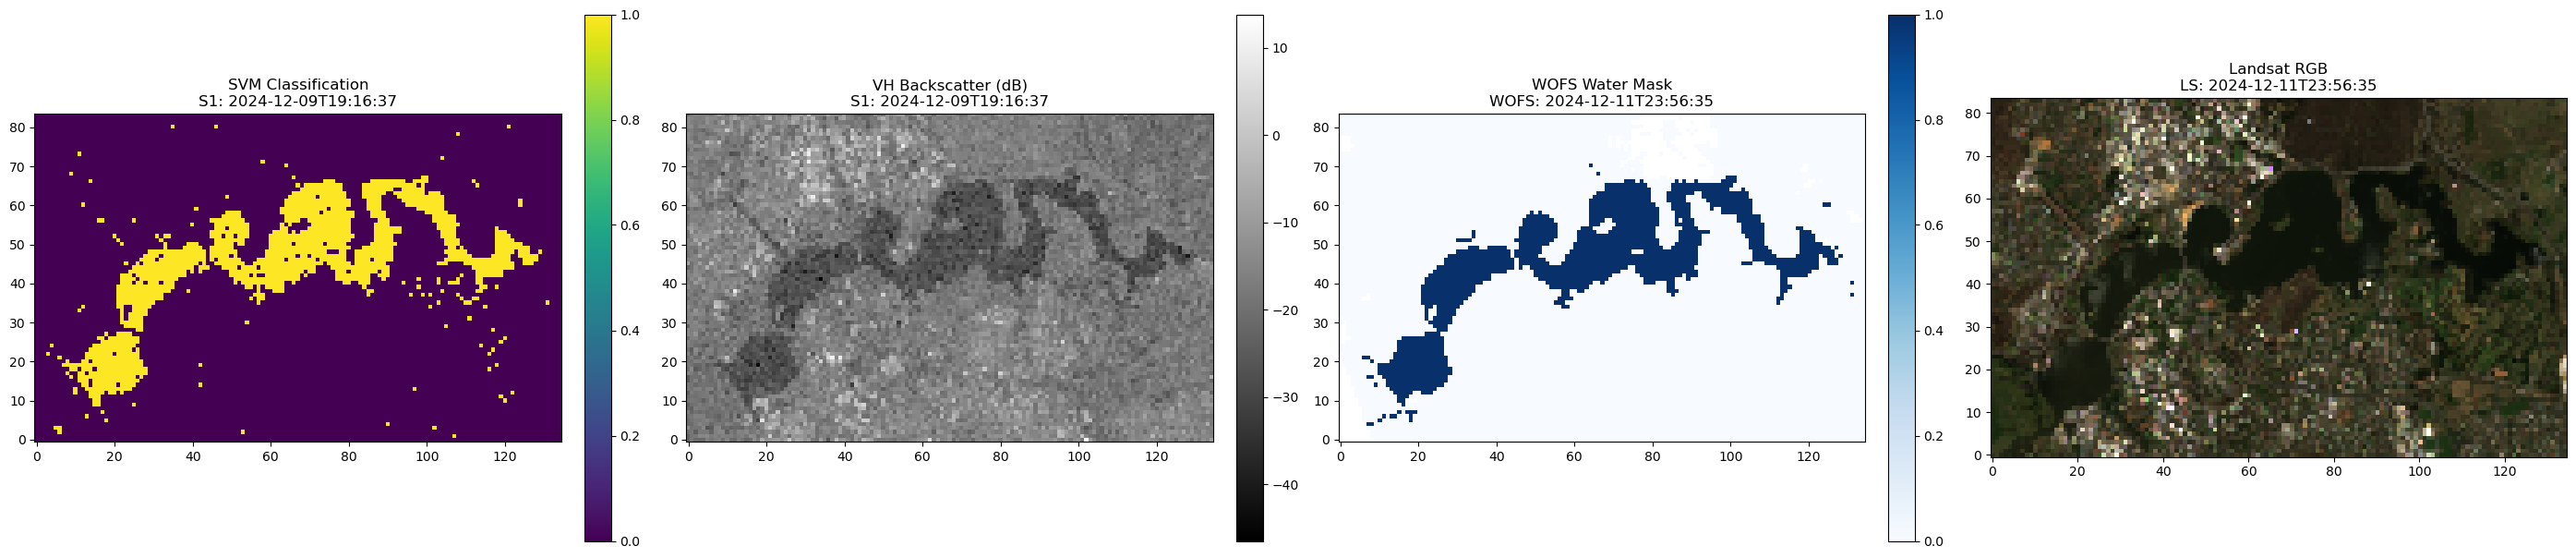

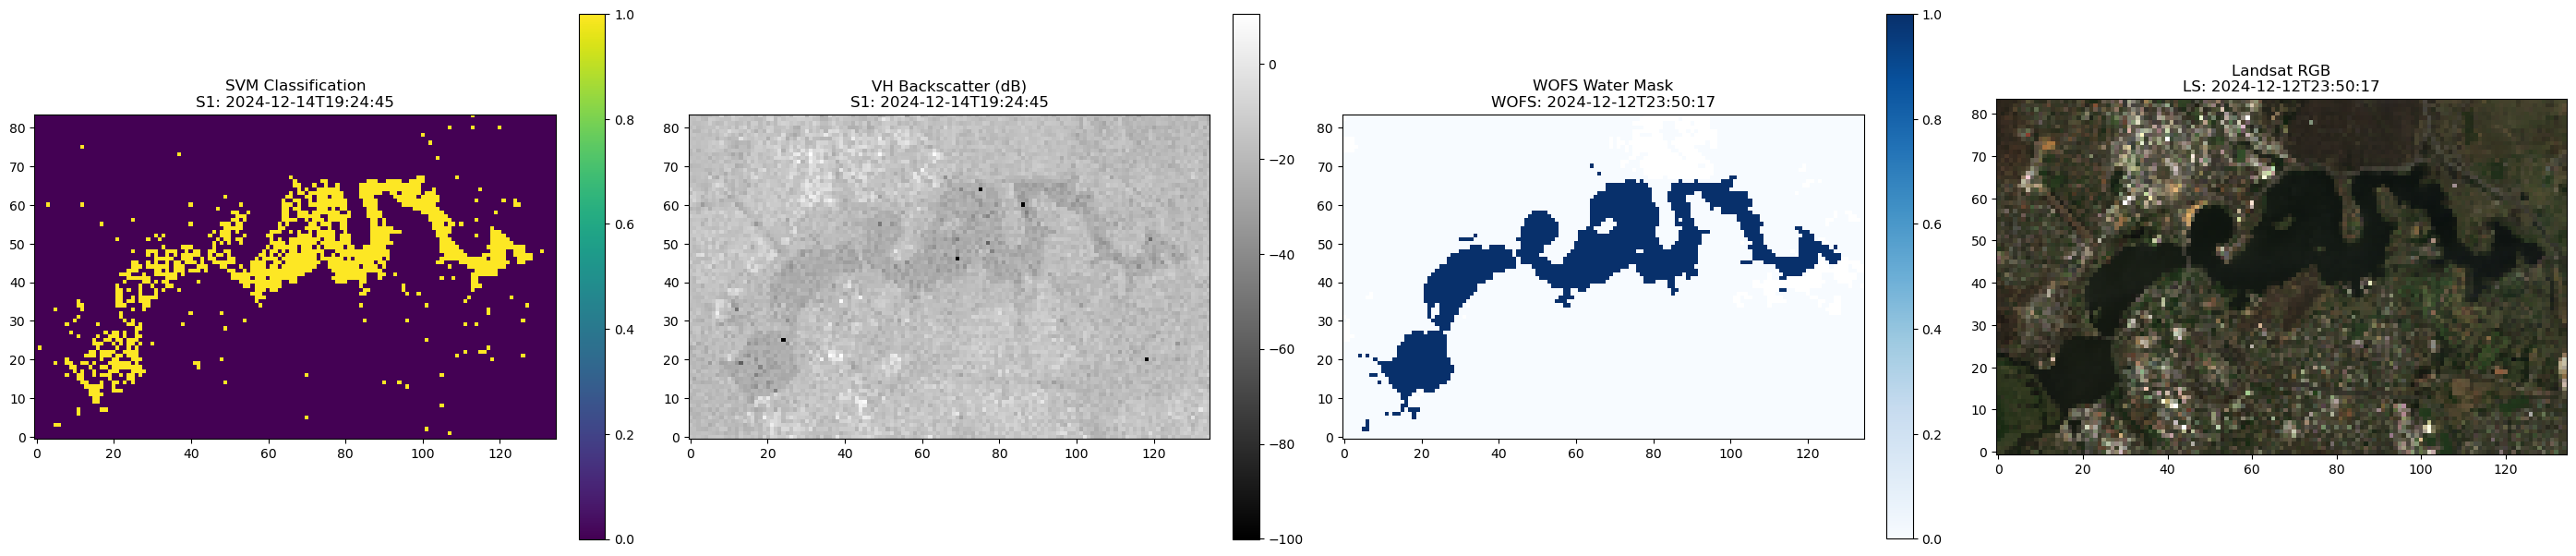

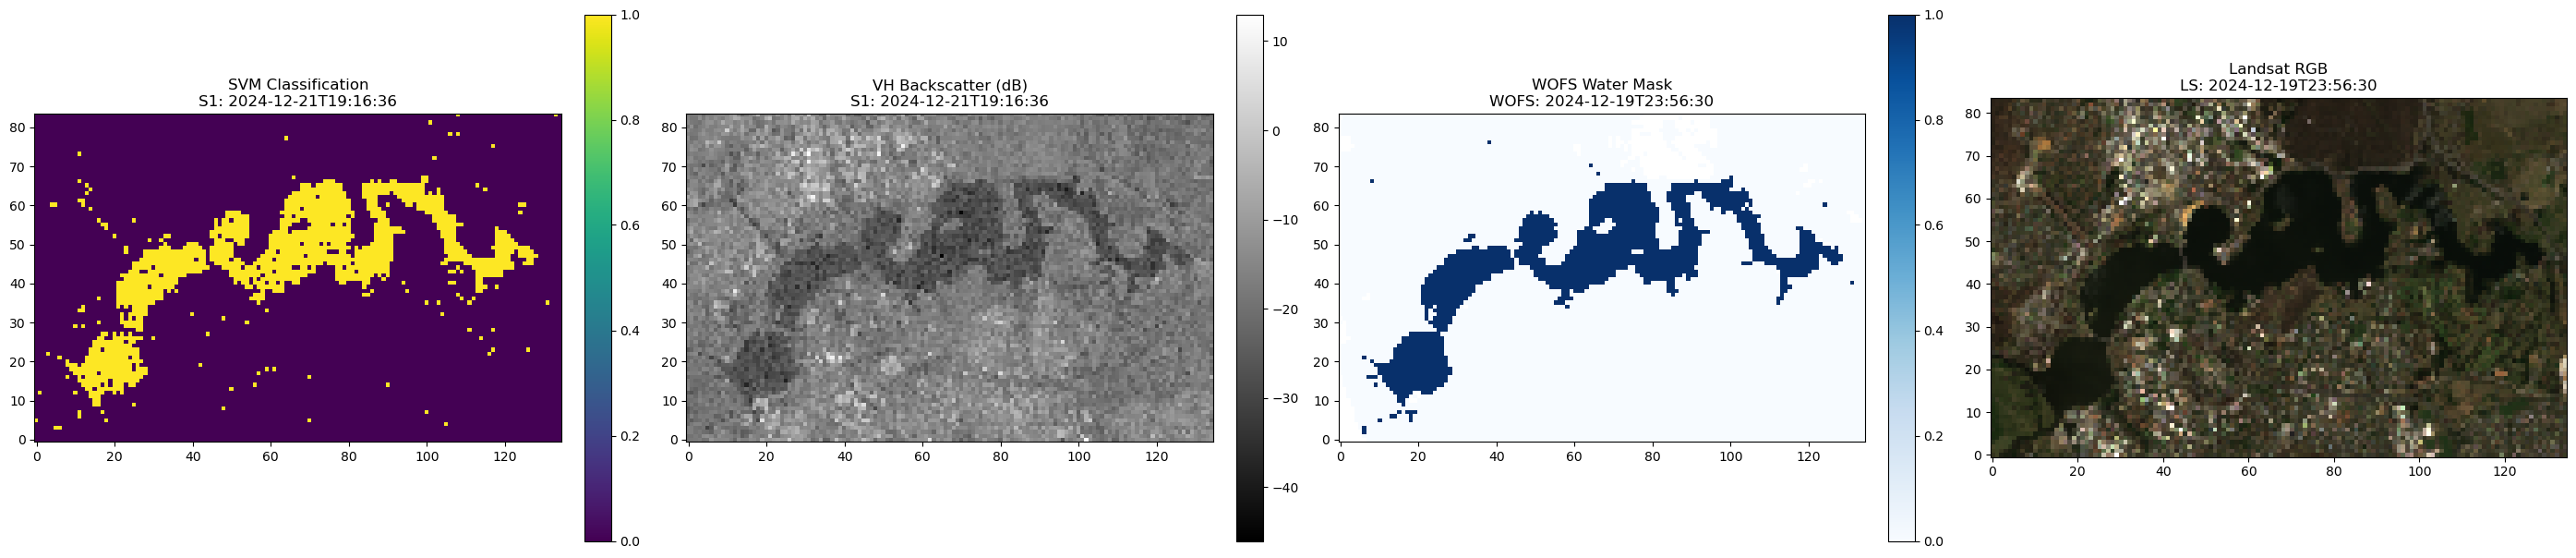

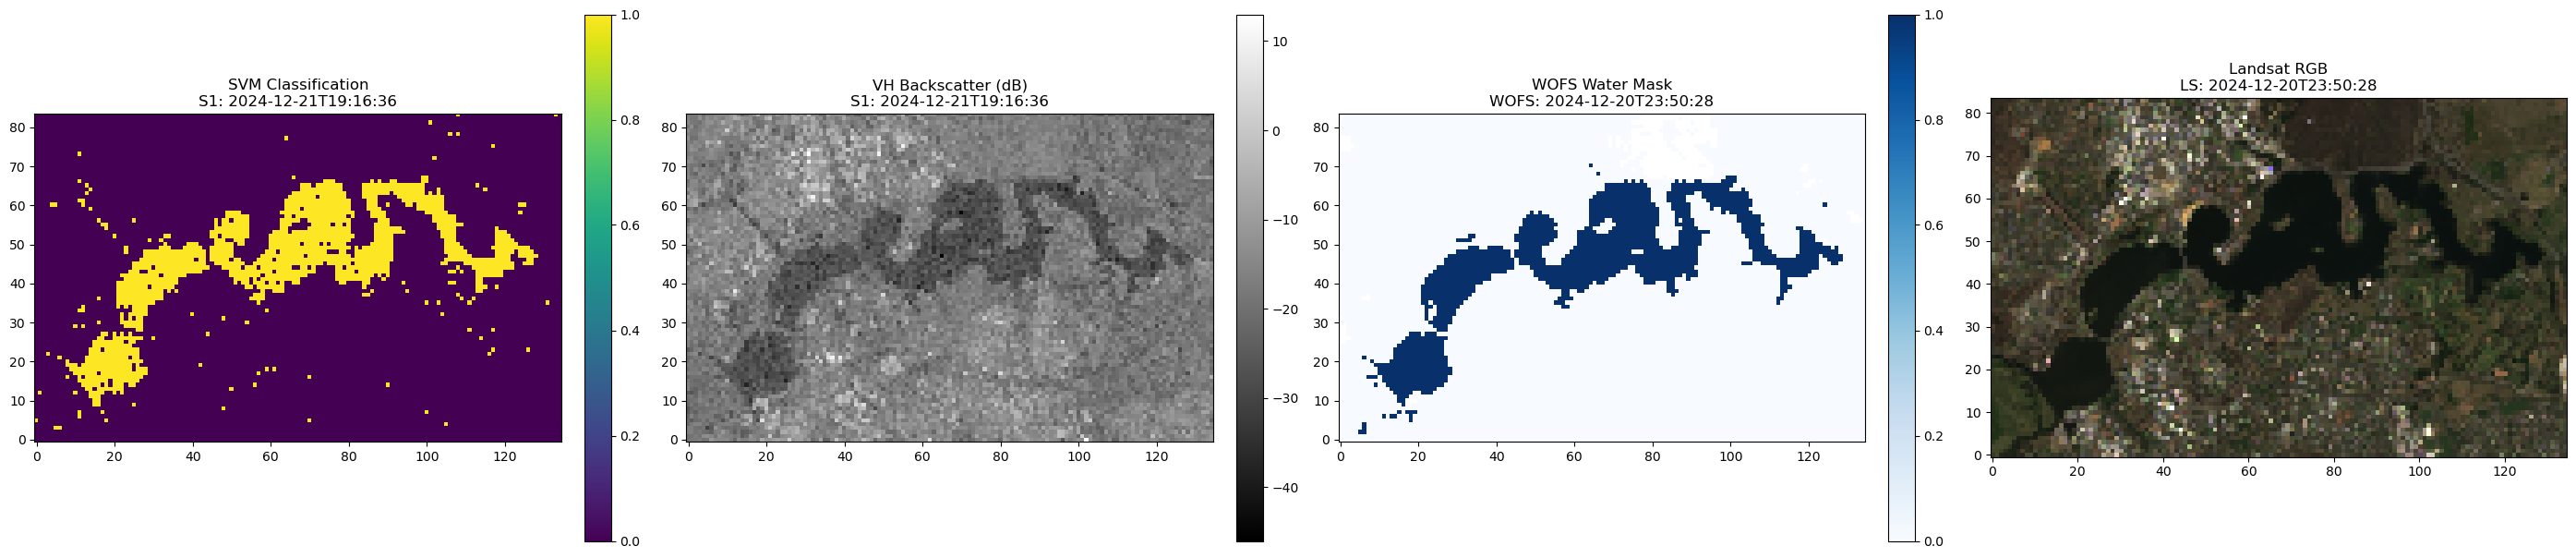

In [16]:
for t in range(s1_matched.time.size):
    # --- Sentinel-1 time ---
    s1_time = np.datetime_as_string(s1_matched.time.values[t], unit="s")

    # --- Sentinel-1 VH and VV slices ---
    vh_slice = s1_matched.VH_gamma0.isel(time=t).values
    vv_slice = s1_matched.VV_gamma0.isel(time=t).values

    # --- Convert to dB and flatten for prediction ---
    bands_db = np.stack((
        10 * np.log10(vh_slice.flatten() + 1e-10),
        10 * np.log10(vv_slice.flatten() + 1e-10)
    ), axis=1)

    # --- Predict SVM classification ---
    classified = clf.predict(bands_db).reshape(vh_slice.shape)

    # --- WOFS ---
    wofs_slice = wo_matched.water.isel(time=t)
    wofs = wofs_slice.values
    wofs_time = np.datetime_as_string(wofs_slice.time.values, unit="s")
    
    # --- Landsat RGB (nearest in time) ---
    ls_rgb = ls.sel(time=wo_matched.time.values[t], method="nearest")
    ls_time = np.datetime_as_string(ls_rgb.time.values, unit="s")
    rgb = np.stack([
        ls_rgb.nbart_red.values,
        ls_rgb.nbart_green.values,
        ls_rgb.nbart_blue.values
    ], axis=-1)
    rgb = np.clip(rgb / 3000, 0, 1)

    # --- VH Backscatter in dB ---
    vh_db = 10 * np.log10(vh_slice + 1e-10)

    # --- Make subplots ---
    fig, axes = plt.subplots(1, 4, figsize=(28, 6))

    # 1. SVM Classification
    im0 = axes[0].imshow(classified, cmap='viridis', origin='lower')
    axes[0].set_title(f"SVM Classification\nS1: {s1_time}")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    # 2. VH Backscatter (dB)
    im1 = axes[1].imshow(vh_db, cmap='gray', origin='lower')
    axes[1].set_title(f"VH Backscatter (dB)\nS1: {s1_time}")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    # 3. WOFS
    im2 = axes[2].imshow(wofs, cmap='Blues', origin='lower')
    axes[2].set_title(f"WOFS Water Mask\nWOFS: {wofs_time}")
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    # 4. Landsat RGB
    axes[3].imshow(rgb, origin='lower')
    axes[3].set_title(f"Landsat RGB\nLS: {ls_time}")

    plt.tight_layout()
    plt.show()